### Normalize and correct sgRNA Log Fold Change data
#### adapted from Fortin et al, 2019
#### by Stefanus Bernard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from _03_01_function_to_normalize_sgrna_lfc import *

In [16]:
read_count = pd.read_excel("../data/sgrna_lfc_data/brunello_data/brunello_A375_Sanson_2018.xlsx", sheet_name="A375_orig_tracr raw reads", skiprows = 2)
read_count = read_count.rename(columns={'sgRNA Sequence':'spacer'})
read_count

# filtered out sgRNA with less than 30 reads in T0
read_count = read_count[read_count['pDNA'] > 30]
display(read_count.head(20))

,spacer,pDNA,RepA,RepB
0,AAAAAAAATCCGGACAATGG,522,729,774
1,AAAAAAAGGATGGTGATCAA,511,1484,1393
2,AAAAAAATGACATTACTGCA,467,375,603
3,AAAAAAATGTCAGTCGAGTG,200,737,506
4,AAAAAACACAAGCAAGACCG,286,672,352
5,AAAAAACAGATGCCACCTGT,213,197,62
6,AAAAAACCAAACTTTGAAGT,215,819,1031
7,AAAAAACCCGTAGATAGCCT,162,347,484
8,AAAAAACCTGGGCAAAACAG,172,296,507
9,AAAAAACCTTCAAAGTACAA,218,781,902


In [17]:
# import library data
library_data = pd.read_csv("../data/library_data/broadgpp-brunello-library-contents.tsv", sep ="\t", header = None)
library_data.columns = ['sgRNA', 'spacer', 'gene']
display(library_data.shape)

(77441, 3)

In [18]:
read_count = pd.merge(read_count, library_data, how="left", on="spacer").set_index(['sgRNA', 'spacer', 'gene']).sort_values(by="sgRNA")
read_count

,,,pDNA,RepA,RepB
sgRNA,spacer,gene,,,
sgA1BG_1,CATCTTCTTTCACCTGAACG,A1BG,563,1670,1411
sgA1BG_2,CTCCGGGGAGAACTCCGGCG,A1BG,472,1144,774
sgA1BG_4,TGGAAGTCCACTCCACTCAG,A1BG,674,1566,1678
sgA1CF_1,ACAGGAAGAATTCAGTTATG,A1CF,537,2314,2006
sgA1CF_2,AGTTATGTTAGGTATACCCG,A1CF,417,1540,1256
...,...,...,...,...,...
sgZZEF1_4,TGCAAGGCTTGACCATCAGT,ZZEF1,633,1248,1376
sgZZZ3_1,ACAGACGATTGCTGTACTCG,ZZZ3,382,184,220
sgZZZ3_2,AGAGTATAACGATGTTCTTG,ZZZ3,525,932,1005


In [19]:
# we log transformed the raw read counts (log2(counts + 1))
log_transformed_read_count = np.log2(read_count + 1)
log_transformed_read_count

,,,pDNA,RepA,RepB
sgRNA,spacer,gene,,,
sgA1BG_1,CATCTTCTTTCACCTGAACG,A1BG,9.139551,10.706496,10.463524
sgA1BG_2,CTCCGGGGAGAACTCCGGCG,A1BG,8.885696,10.161132,9.598053
sgA1BG_4,TGGAAGTCCACTCCACTCAG,A1BG,9.398744,10.613789,10.713387
sgA1CF_1,ACAGGAAGAATTCAGTTATG,A1CF,9.071462,11.176796,10.970825
sgA1CF_2,AGTTATGTTAGGTATACCCG,A1CF,8.707359,10.589651,10.295769
...,...,...,...,...,...
sgZZEF1_4,TGCAAGGCTTGACCATCAGT,ZZEF1,9.308339,10.286558,10.427313
sgZZZ3_1,ACAGACGATTGCTGTACTCG,ZZZ3,8.581201,7.531381,7.787903
sgZZZ3_2,AGAGTATAACGATGTTCTTG,ZZZ3,9.038919,9.865733,9.974415


In [20]:
pDNA = log_transformed_read_count[['pDNA']]

# Compute log-fold change relative to T0
sgrna_lfc = log_transformed_read_count.drop(columns=['pDNA']).subtract(pDNA.values, axis = 0)
sgrna_lfc

,,,RepA,RepB
sgRNA,spacer,gene,,
sgA1BG_1,CATCTTCTTTCACCTGAACG,A1BG,1.566945,1.323973
sgA1BG_2,CTCCGGGGAGAACTCCGGCG,A1BG,1.275436,0.712356
sgA1BG_4,TGGAAGTCCACTCCACTCAG,A1BG,1.215046,1.314643
sgA1CF_1,ACAGGAAGAATTCAGTTATG,A1CF,2.105334,1.899363
sgA1CF_2,AGTTATGTTAGGTATACCCG,A1CF,1.882292,1.588410
...,...,...,...,...
sgZZEF1_4,TGCAAGGCTTGACCATCAGT,ZZEF1,0.978219,1.118974
sgZZZ3_1,ACAGACGATTGCTGTACTCG,ZZZ3,-1.049819,-0.793298
sgZZZ3_2,AGAGTATAACGATGTTCTTG,ZZZ3,0.826814,0.935496


In [21]:
# Center LFCs using non-essential guides
non_essential_mask = ~log_transformed_read_count.index.get_level_values(2).isin(["Non-Targeting Control"])
median_non_essential = sgrna_lfc[non_essential_mask].median(axis=0)

median_non_essential

RepA    1.333981
RepB    1.259472
dtype: float64

In [22]:
# Subtract median of non-essential guides for each sample (normalized sgrna LFC)
sgrna_lfc_normalized = sgrna_lfc - median_non_essential
sgrna_lfc_normalized

,,,RepA,RepB
sgRNA,spacer,gene,,
sgA1BG_1,CATCTTCTTTCACCTGAACG,A1BG,0.232964,0.064501
sgA1BG_2,CTCCGGGGAGAACTCCGGCG,A1BG,-0.058545,-0.547116
sgA1BG_4,TGGAAGTCCACTCCACTCAG,A1BG,-0.118935,0.055171
sgA1CF_1,ACAGGAAGAATTCAGTTATG,A1CF,0.771353,0.639891
sgA1CF_2,AGTTATGTTAGGTATACCCG,A1CF,0.548311,0.328938
...,...,...,...,...
sgZZEF1_4,TGCAAGGCTTGACCATCAGT,ZZEF1,-0.355762,-0.140498
sgZZZ3_1,ACAGACGATTGCTGTACTCG,ZZZ3,-2.383800,-2.052770
sgZZZ3_2,AGAGTATAACGATGTTCTTG,ZZZ3,-0.507167,-0.323976


In [23]:
# scaled sgRNA log fold change by centering around the median LFC of guides targeting essential genes
norm_sgrna_lfc_scaled, list_common_essential = scale_essential(sgrna_lfc_normalized)
norm_sgrna_lfc_scaled

Scale factor:  2.5941283958482484


,,,RepA,RepB
sgRNA,spacer,gene,,
sgA1BG_1,CATCTTCTTTCACCTGAACG,A1BG,0.089804,0.024864
sgA1BG_2,CTCCGGGGAGAACTCCGGCG,A1BG,-0.022568,-0.210905
sgA1BG_4,TGGAAGTCCACTCCACTCAG,A1BG,-0.045848,0.021268
sgA1CF_1,ACAGGAAGAATTCAGTTATG,A1CF,0.297346,0.246669
sgA1CF_2,AGTTATGTTAGGTATACCCG,A1CF,0.211366,0.126801
...,...,...,...,...
sgZZEF1_4,TGCAAGGCTTGACCATCAGT,ZZEF1,-0.137141,-0.054160
sgZZZ3_1,ACAGACGATTGCTGTACTCG,ZZZ3,-0.918921,-0.791314
sgZZZ3_2,AGAGTATAACGATGTTCTTG,ZZZ3,-0.195506,-0.124888


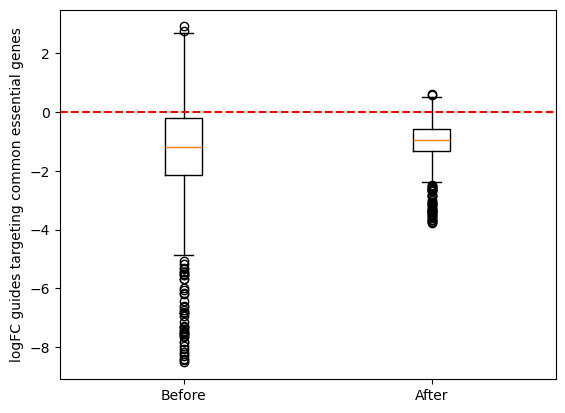

In [24]:
# check whether the normalization works (the median of lfc data should be around 0)
sanity_check_scale_essential(sgrna_lfc, norm_sgrna_lfc_scaled, list_common_essential)

In [27]:
# averaged sgRNA LFC across replicates
lfc_norm_scaled_avg = mean_row(norm_sgrna_lfc_scaled)
lfc_norm_scaled_avg = lfc_norm_scaled_avg.reset_index()
lfc_norm_scaled_avg

,sgRNA,spacer,gene,mean
0,sgA1BG_1,CATCTTCTTTCACCTGAACG,A1BG,0.057334
1,sgA1BG_2,CTCCGGGGAGAACTCCGGCG,A1BG,-0.116737
2,sgA1BG_4,TGGAAGTCCACTCCACTCAG,A1BG,-0.012290
3,sgA1CF_1,ACAGGAAGAATTCAGTTATG,A1CF,0.272007
4,sgA1CF_2,AGTTATGTTAGGTATACCCG,A1CF,0.169084
...,...,...,...,...
76903,sgZZEF1_4,TGCAAGGCTTGACCATCAGT,ZZEF1,-0.095651
76904,sgZZZ3_1,ACAGACGATTGCTGTACTCG,ZZZ3,-0.855118
76905,sgZZZ3_2,AGAGTATAACGATGTTCTTG,ZZZ3,-0.160197
76906,sgZZZ3_3,GCAGAGTACCCGAGAATCAT,ZZZ3,0.067745


In [28]:
lfc_norm_scaled_avg.to_csv("../data/sgrna_lfc_data/output_normalized/brunello_a375_normalized_lfc.csv", index=False)